In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка данных
df = pd.read_csv('train.csv')

# Дополнительные признаки для расширенного анализа
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Deck'] = df['Cabin'].str[0].fillna('Unknown')
df.head()

<Figure size 1000x500 with 0 Axes>

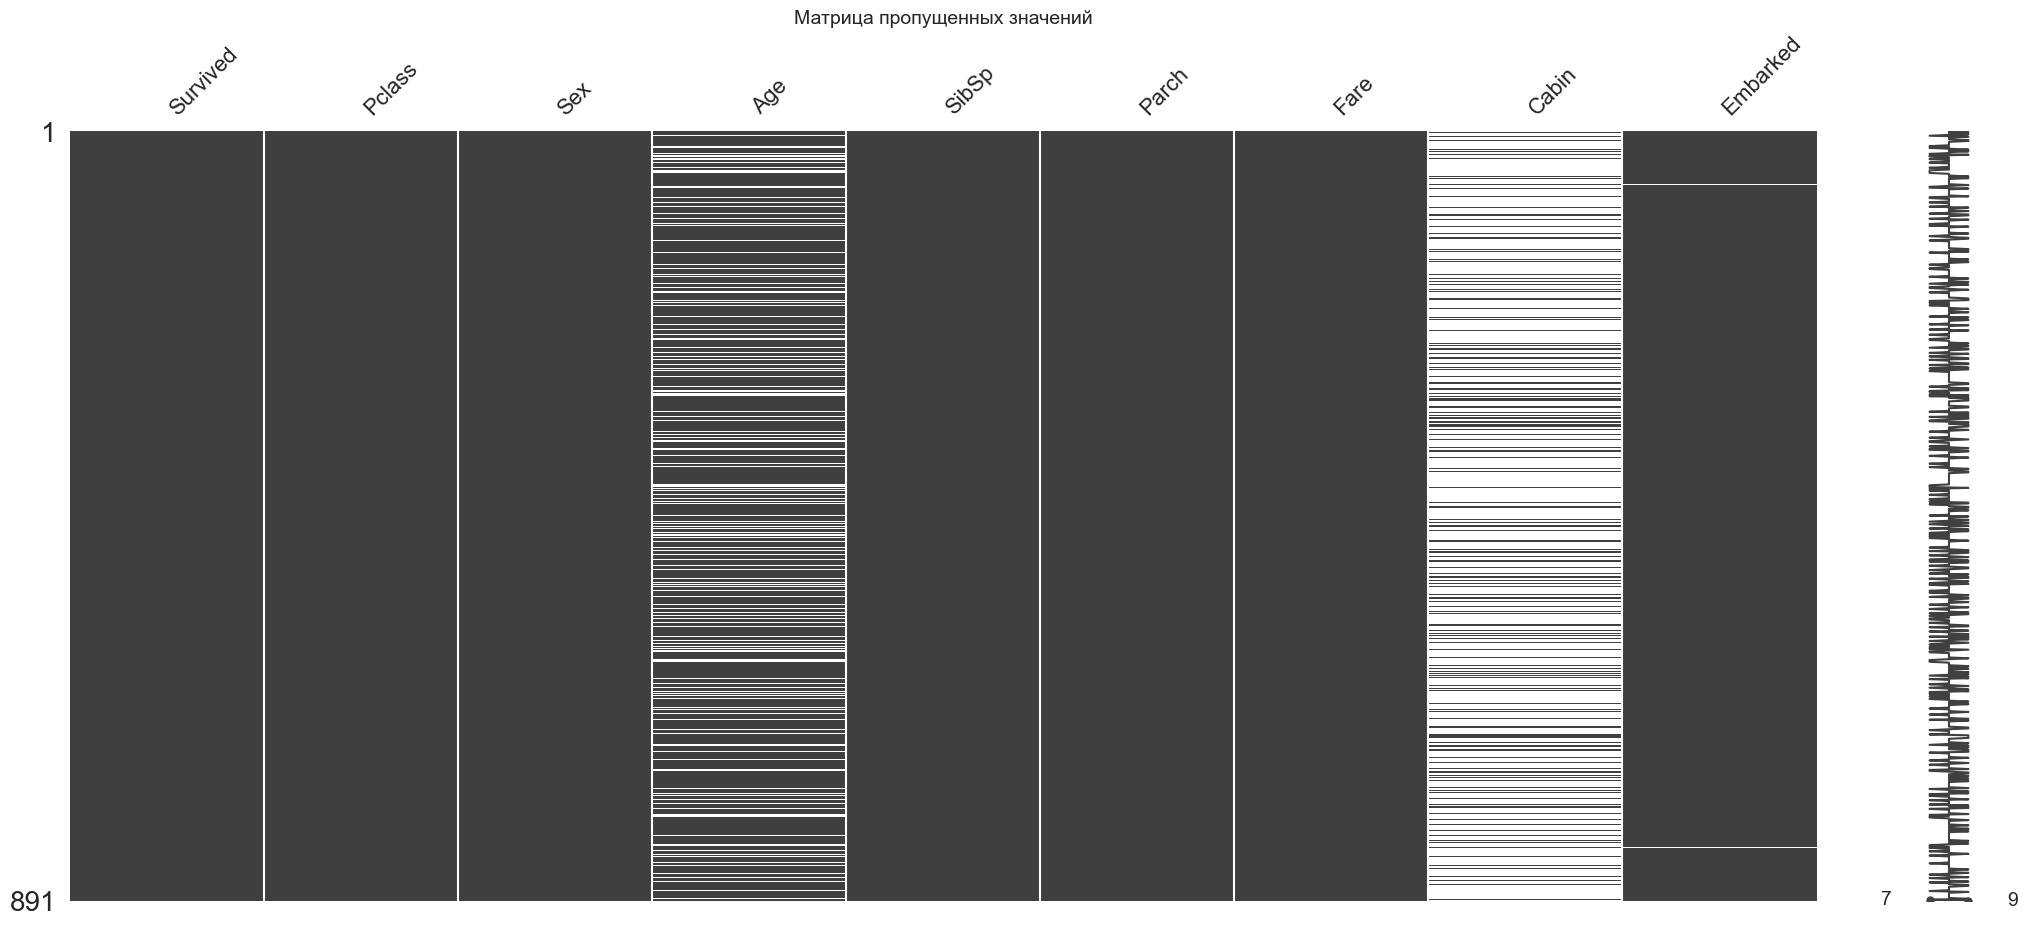

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\2854155711.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')


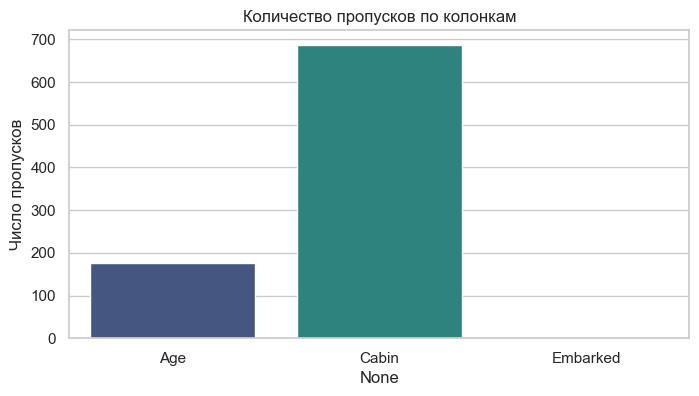

In [ ]:
# Матрица пропусков
plt.figure(figsize=(10, 5))
msno.matrix(df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']])
plt.title('Матрица пропущенных значений', fontsize=14)
plt.show()

# Столбчатая диаграмма количества пропусков
plt.figure(figsize=(8, 4))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title('Количество пропусков по колонкам')
plt.ylabel('Число пропусков')
plt.show()

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\149276486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')


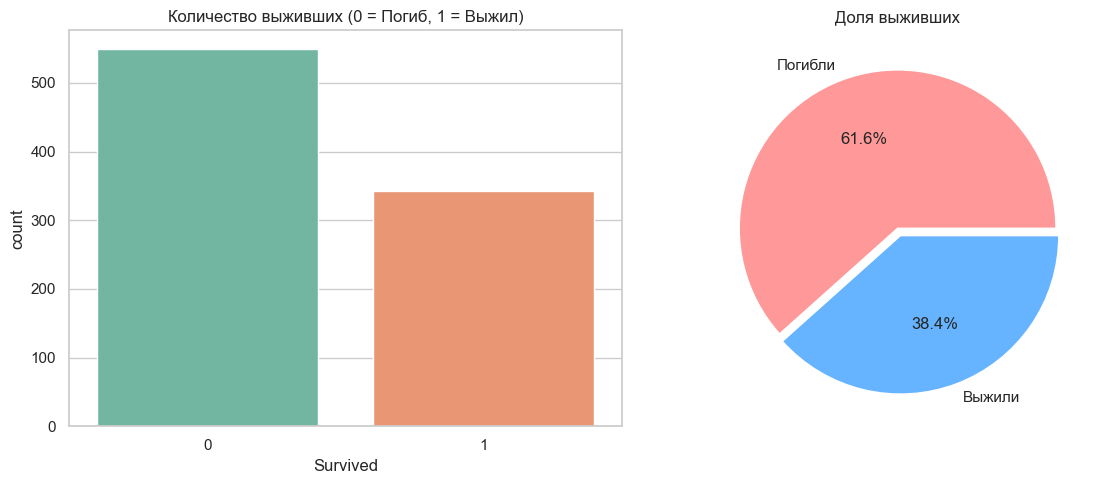

In [ ]:
# Распределение целевой переменной Survived (Count Plot и Pie Chart)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Количество выживших (0 = Погиб, 1 = Выжил)')

df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], labels=['Погибли', 'Выжили'], colors=['#ff9999','#66b3ff'], explode=[0, 0.05])
axes[1].set_ylabel('')
axes[1].set_title('Доля выживших')
plt.tight_layout()
plt.show()

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1993842075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', ax=axes[0], palette='pastel')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1993842075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', ax=axes[1], palette='pastel')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1993842075.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Embarked', ax=axes[2], palette='pastel')


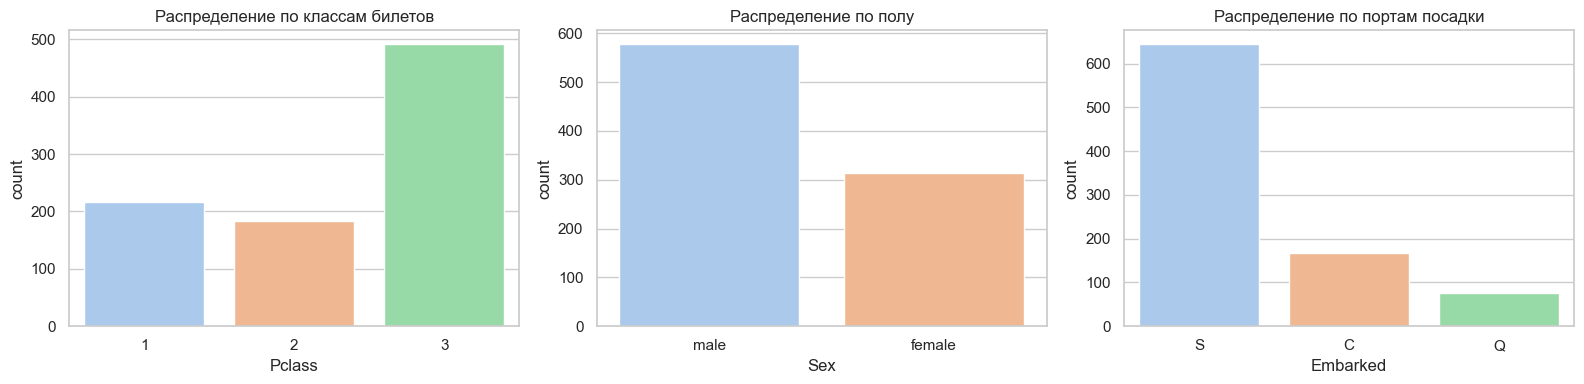

In [ ]:
# Категориальные признаки: Pclass, Sex, Embarked
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='Pclass', ax=axes[0], palette='pastel')
axes[0].set_title('Распределение по классам билетов')
sns.countplot(data=df, x='Sex', ax=axes[1], palette='pastel')
axes[1].set_title('Распределение по полу')
sns.countplot(data=df, x='Embarked', ax=axes[2], palette='pastel')
axes[2].set_title('Распределение по портам посадки')
plt.tight_layout()
plt.show()

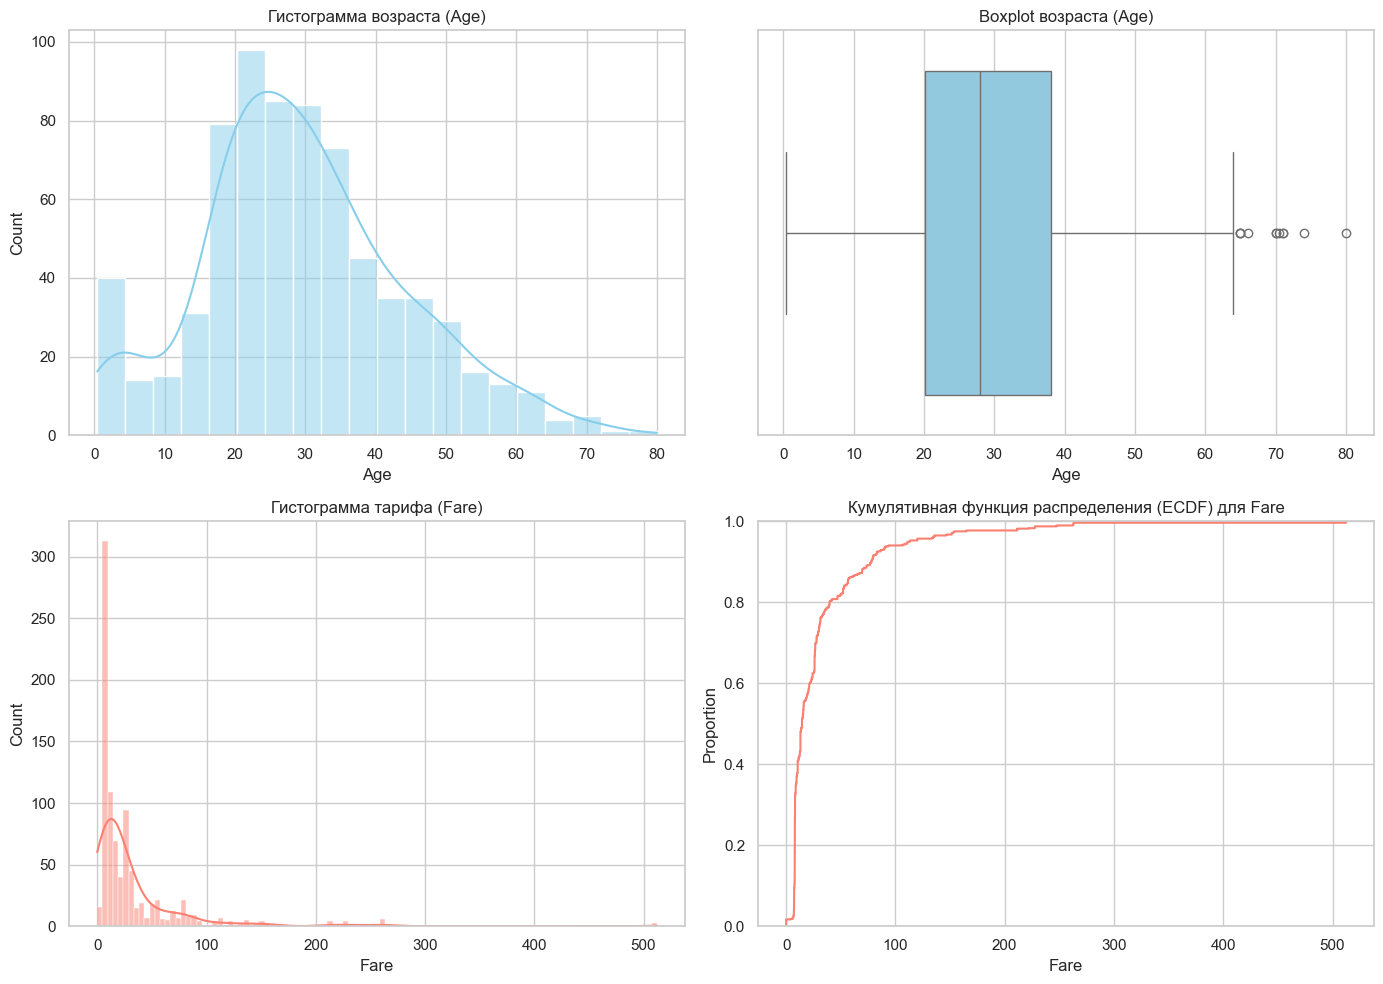

In [ ]:
# Числовые признаки: Age и Fare (Гистограммы с KDE, Boxplot, ECDF)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Гистограмма возраста (Age)')

sns.boxplot(x=df['Age'], ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Boxplot возраста (Age)')

sns.histplot(df['Fare'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Гистограмма тарифа (Fare)')

sns.ecdfplot(data=df, x='Fare', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Кумулятивная функция распределения (ECDF) для Fare')

plt.tight_layout()
plt.show()

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1651434716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], palette='muted')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1651434716.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], palette='muted')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\1651434716.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2], palette='muted')


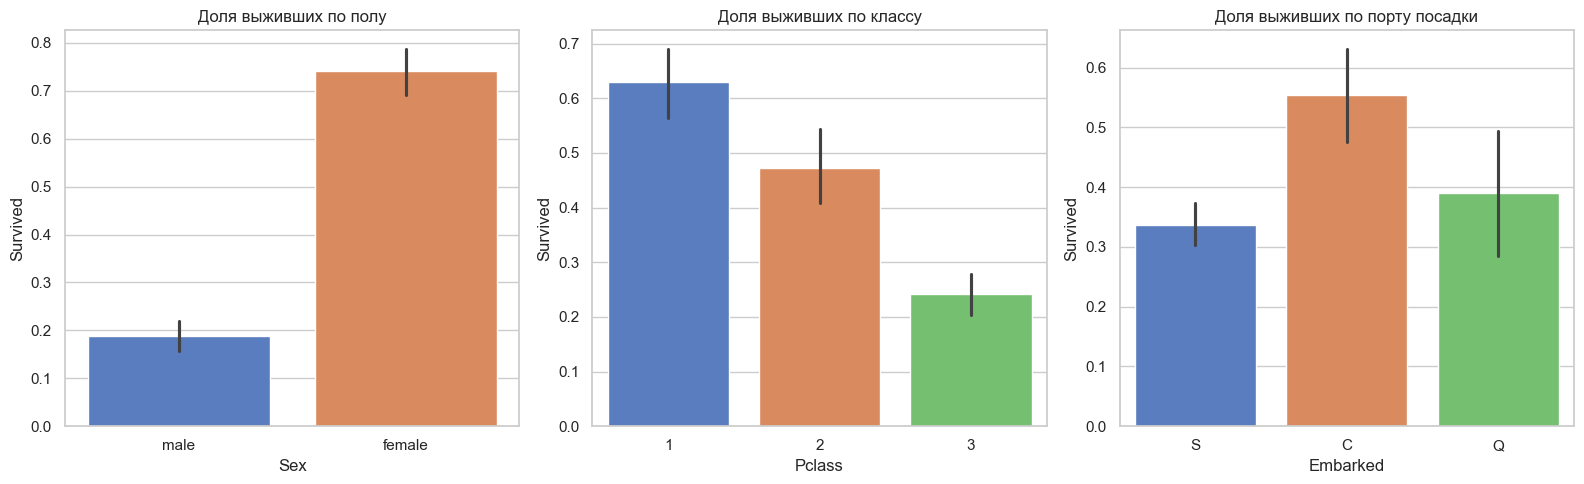

In [ ]:
# Взаимосвязь категориальных признаков с Survived
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], palette='muted')
axes[0].set_title('Доля выживших по полу')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], palette='muted')
axes[1].set_title('Доля выживших по классу')

sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2], palette='muted')
axes[2].set_title('Доля выживших по порту посадки')

plt.tight_layout()
plt.show()

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\2847708344.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='coolwarm', ax=axes[1])


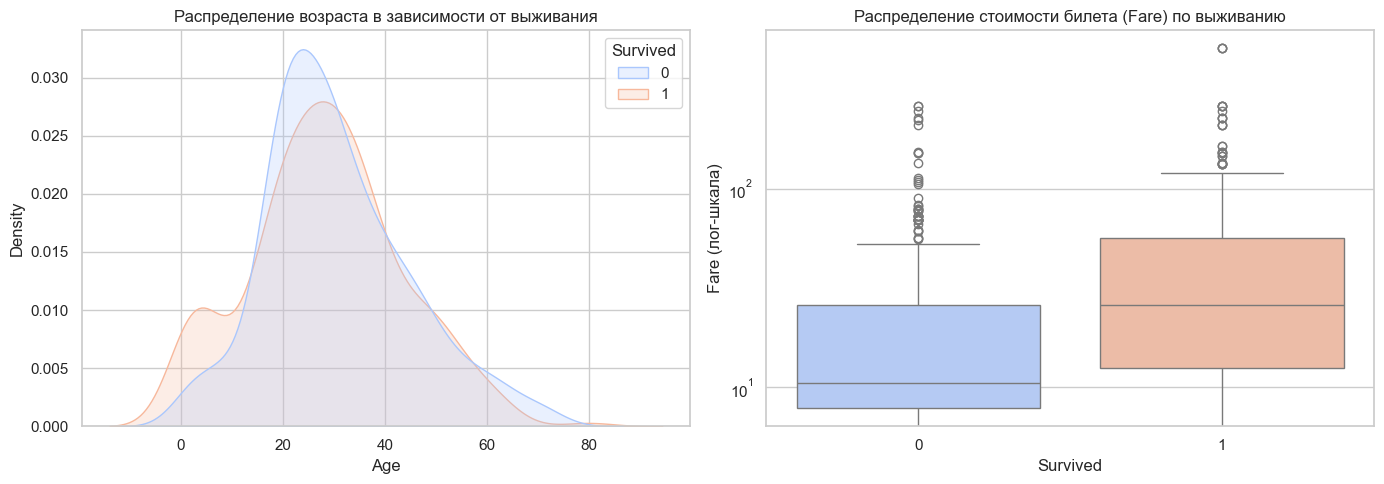

In [ ]:
# Числовые признаки vs Survived (KDE и Boxplot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, fill=True, palette='coolwarm', ax=axes[0])
axes[0].set_title('Распределение возраста в зависимости от выживания')

sns.boxplot(data=df, x='Survived', y='Fare', palette='coolwarm', ax=axes[1])
axes[1].set_title('Распределение стоимости билета (Fare) по выживанию')
axes[1].set_yscale('log')
axes[1].set_ylabel('Fare (лог-шкала)')

plt.tight_layout()
plt.show()

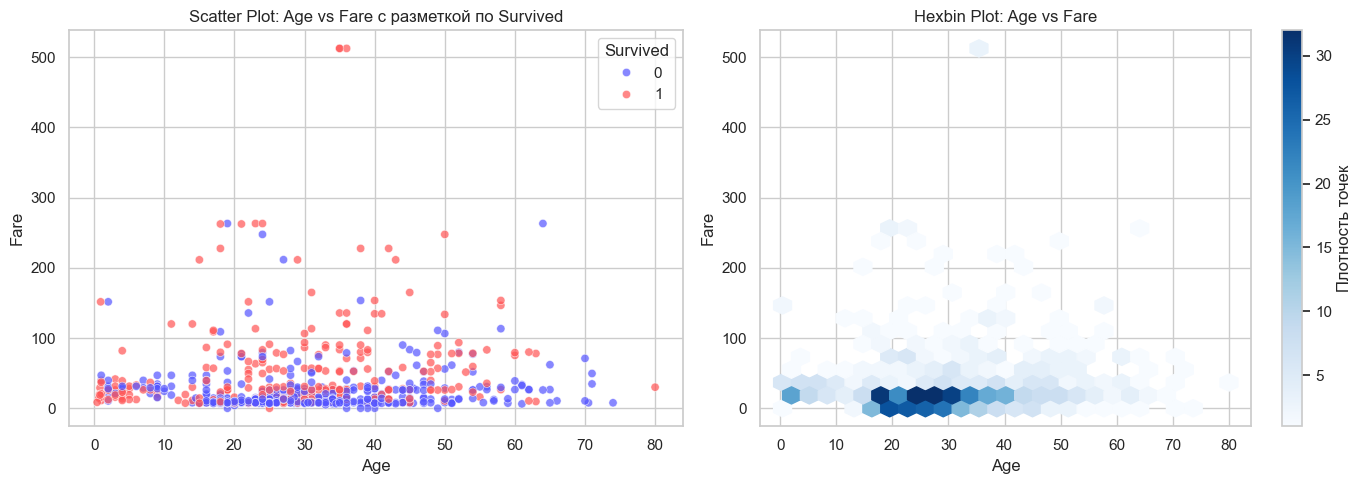

In [ ]:
# Взаимосвязь Age и Fare (Scatter Plot и Hexbin Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.7, ax=axes[0], palette='seismic')
axes[0].set_title('Scatter Plot: Age vs Fare с разметкой по Survived')

hb = axes[1].hexbin(df['Age'].dropna(), df.loc[df['Age'].notnull(), 'Fare'], gridsize=25, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[1], label='Плотность точек')
axes[1].set_title('Hexbin Plot: Age vs Fare')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

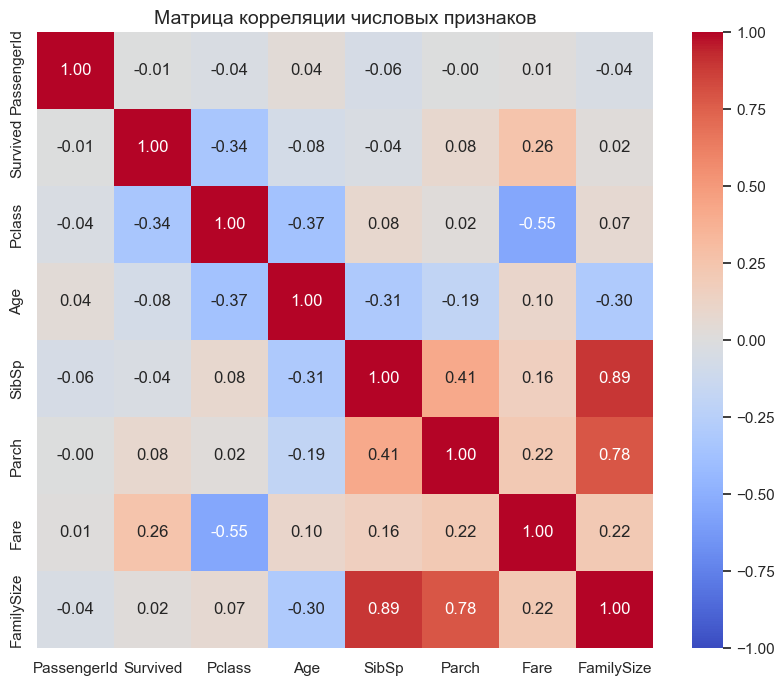

In [ ]:
# Матрица корреляции
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', square=True)
plt.title('Матрица корреляции числовых признаков', fontsize=14)
plt.show()

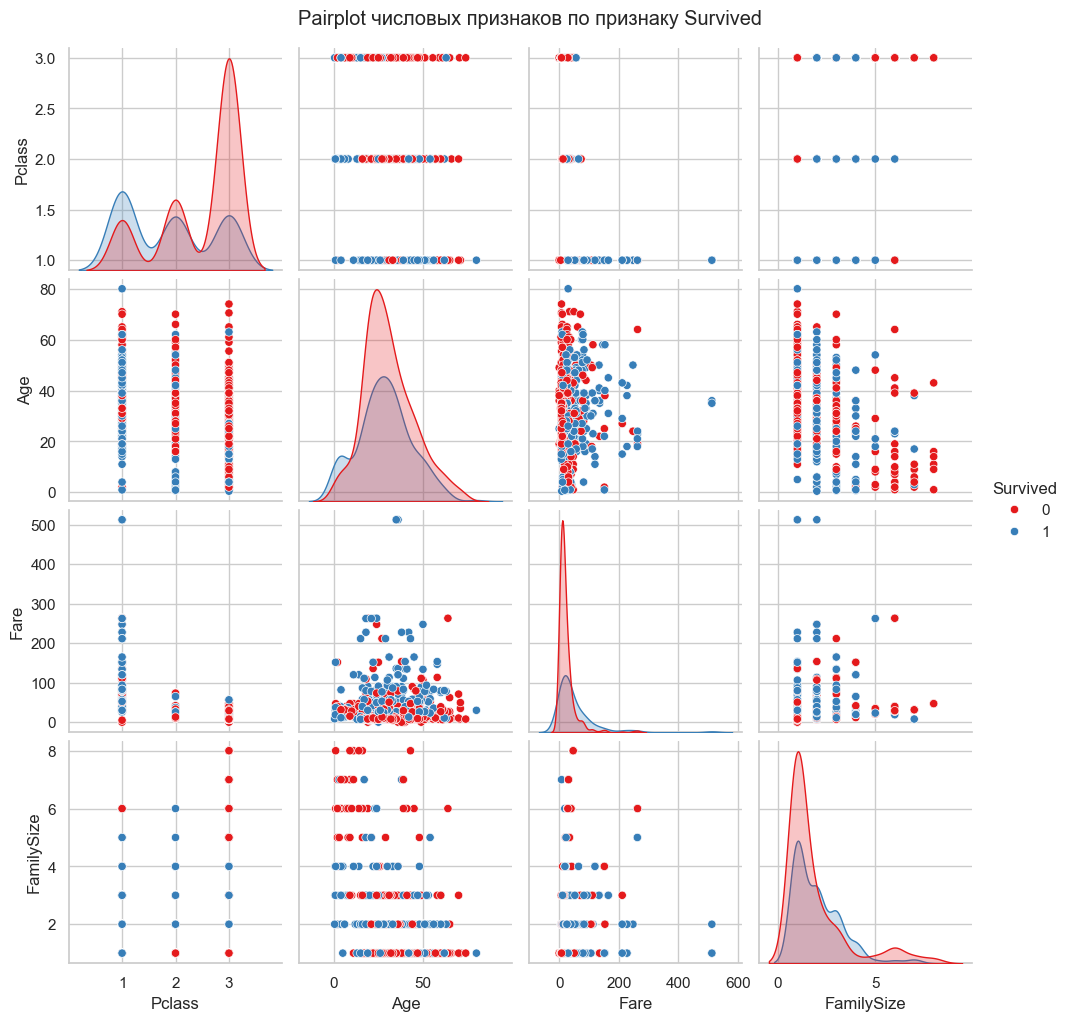

In [ ]:
# Сетка попарных распределений (Pairplot)
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare', 'FamilySize']].dropna(), hue='Survived', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot числовых признаков по признаку Survived', y=1.02)
plt.show()

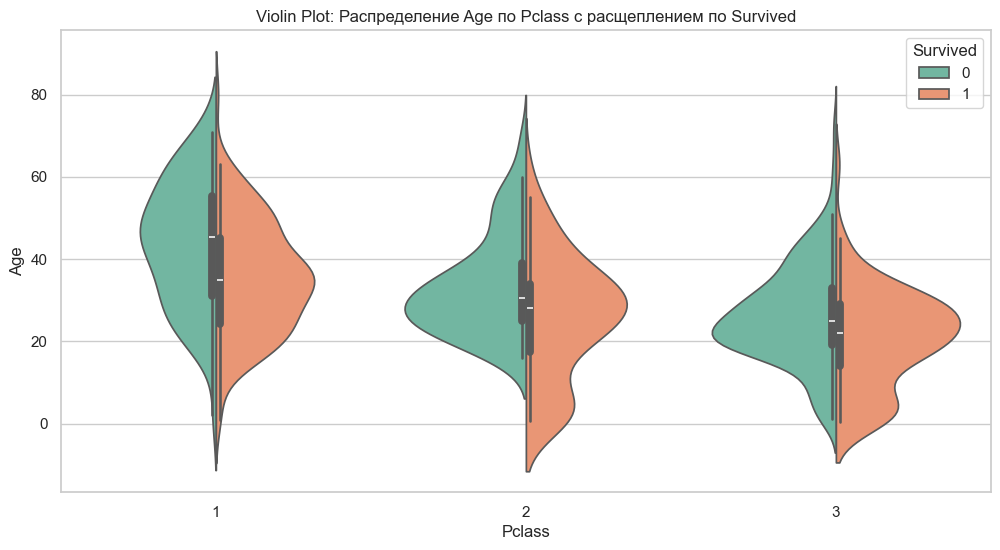

In [ ]:
# Скрипичные графики с расщеплением: Pclass, Age, Sex, Survived
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', split=True, palette='Set2')
plt.title('Violin Plot: Распределение Age по Pclass с расщеплением по Survived')
plt.show()

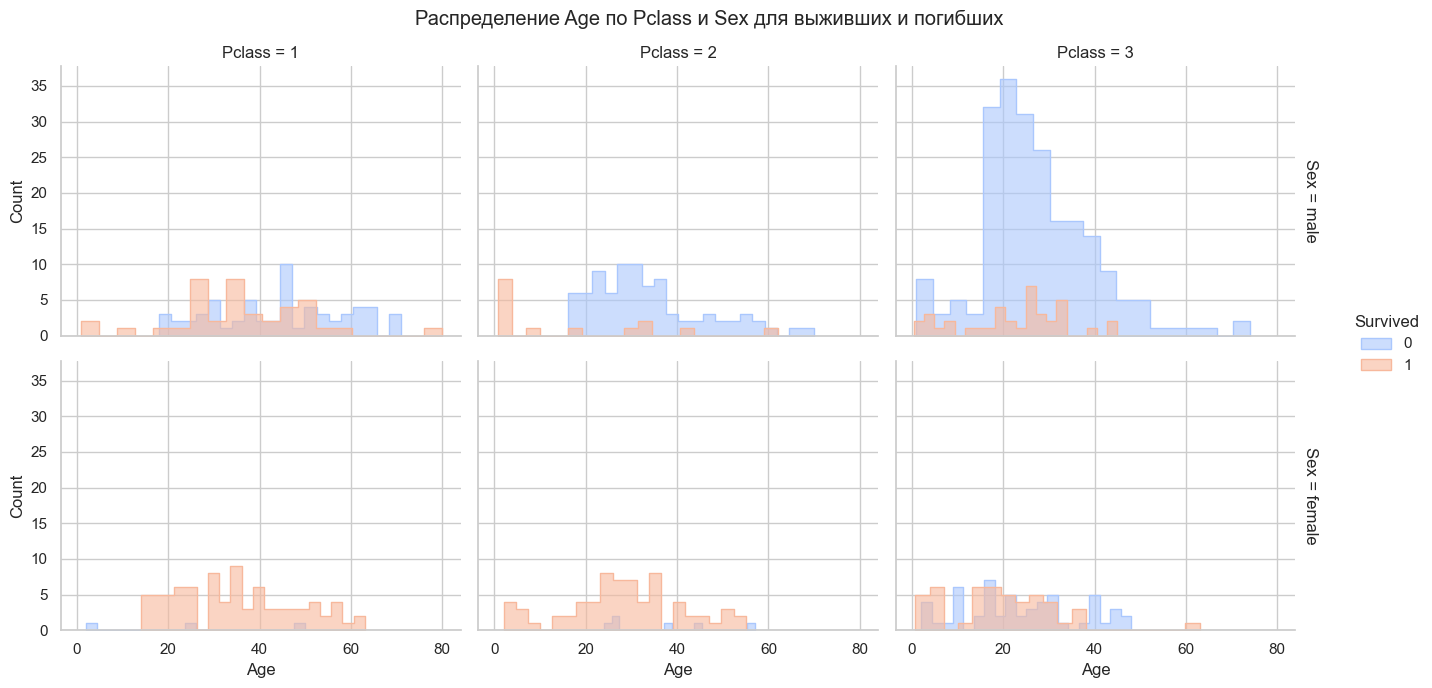

In [ ]:
# Фасетная сетка FacetGrid: Age vs Survived в разрезе Sex и Pclass
g = sns.FacetGrid(df, col='Pclass', row='Sex', hue='Survived', margin_titles=True, height=3.5, aspect=1.3, palette='coolwarm')
g.map(sns.histplot, 'Age', bins=20, alpha=0.6, element='step')
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Распределение Age по Pclass и Sex для выживших и погибших')
plt.show()

C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\917460866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[0], palette='Blues_d')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\917460866.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Title', y='Survived', ax=axes[1], palette='Purples_d')
C:\Users\bazdi\AppData\Local\Temp\ipykernel_16408\917460866.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Deck'] != 'Unknown'], x='Deck', y='Survived', order=sorted(df

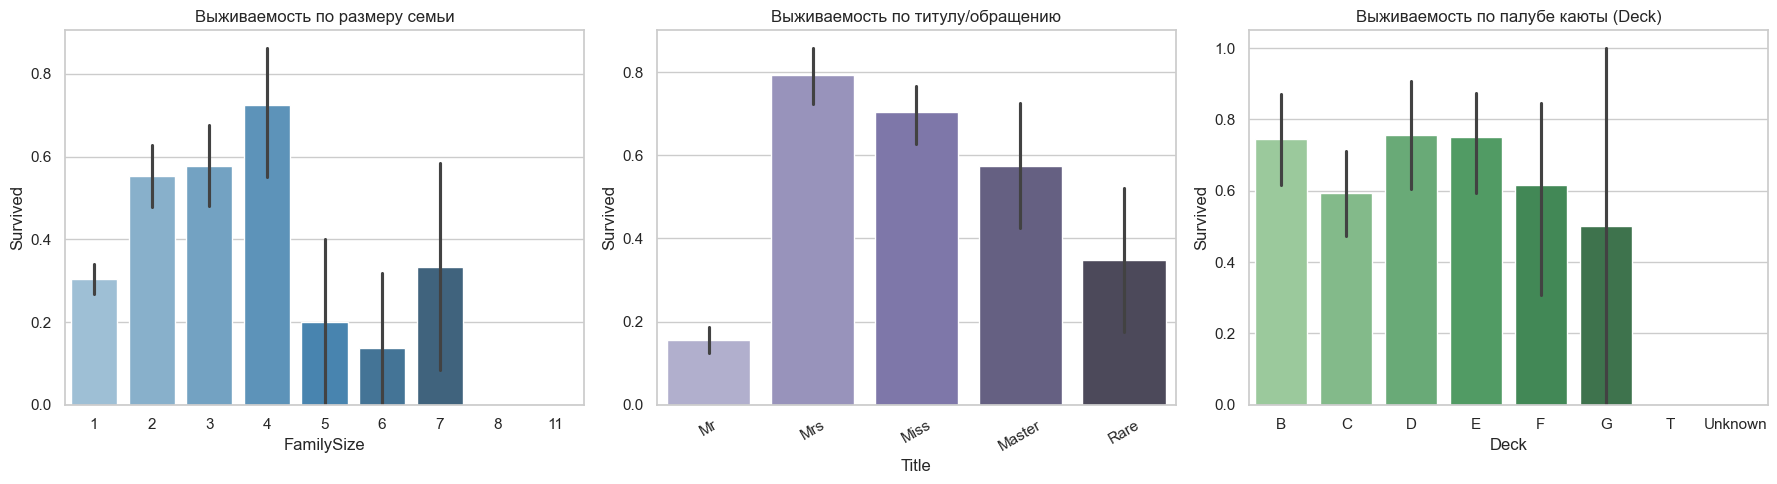

In [ ]:
# Зависимость выживаемости от FamilySize, Title и Deck
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[0], palette='Blues_d')
axes[0].set_title('Выживаемость по размеру семьи')

sns.barplot(data=df, x='Title', y='Survived', ax=axes[1], palette='Purples_d')
axes[1].set_title('Выживаемость по титулу/обращению')
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=df[df['Deck'] != 'Unknown'], x='Deck', y='Survived', order=sorted(df['Deck'].unique())[1:], ax=axes[2], palette='Greens_d')
axes[2].set_title('Выживаемость по палубе каюты (Deck)')

plt.tight_layout()
plt.show()